# Procesamiento de Lenguaje Natural


**Angel Navia Vázquez**

  * 1.1 (January 2026)

Departamento de Teoría de la Señal y Comunicaciones

**Universidad Carlos III de Madrid**

<img src='http://www.tsc.uc3m.es/~navia/figures/logo_uc3m_foot.jpg' width=400 />

# Proyecto I: clasificación de textos

**AUTOR(ES):**

-  **Apellidos1, Nombre1**

-  **Apellidos2, Nombre2**


El objetivo es entrenar un clasificador para identificar si una noticia pertenece o no a una categoría determinada. En este caso utilizaremos el conjunto de datos **Reuters-21578** incluido en NLTK (Natural Language Toolkit), que es un corpus clásico utilizado para la categorización de textos (clasificación). Contiene noticias breves de la agencia Reuters, publicadas en 1987, etiquetadas según su pertenencia a determinados temas financieros y económicos (Informes de ganancias/ingresos financieros de empresas, Adquisiciones, fusiones o compra de empresas, Divisas, mercados de divisas y tasas de cambio, Noticias sobre granos y cereales, etc. Elegiremos como objetivo la **categoría "crude"**, es decir queremos construir un clasificador que nos permita **recuperar todas las noticias sobre "petróleo crudo y mercados de petróleo"**.

Se deberán **realizar las siguientes operaciones**, usando alguno de los métodos vistos hasta ahora en la asignatura:

- **Obtener la base de datos desde NLTK (corpus reuters)**.
- **Preprocesar los documentos**.
- **Vectorizar los documentos**.
- **Construir datos de entrenamiento y test** (X_train, Y_train, X_test, Y_test), tal que los datos de test sean el 30% del total de los datos.
- **Entrenar un clasificador**, eligiendo el mejor valor de los hiperparámetros usando **validación cruzada 10-fold**.
- **Mostrar la curva de Precisión-Recall** y el **F1 score** resultante.

---
## Paso 0: Configuración del entorno optimizada para Apple Silicon M2 Pro

El MacBook Pro M2 Pro cuenta con:
- **10 núcleos de CPU** (6 de rendimiento + 4 de eficiencia) + 2 núcleos adicionales en algunas configuraciones
- **16 núcleos de GPU** (integrada en el SoC)
- **Motor Neural de 16 núcleos** (Apple Neural Engine, ANE)
- **Bloques AMX** (Apple Matrix coprocessor) para multiplicación de matrices acelerada
- **Memoria unificada** (CPU y GPU comparten la misma RAM, eliminando transferencias)

### Optimizaciones aplicadas:
1. **`spacy[apple]`** → activa `thinc-apple-ops`, que usa Apple Accelerate/AMX para multiplicación de matrices (hasta 8x más rápido)
2. **`nlp.pipe()` con batching** → reutiliza recursos internos de SpaCy entre documentos, evitando overhead de creación/destrucción
3. **Desactivación de componentes SpaCy innecesarios** (`ner`, `parser`) → solo necesitamos lematización y POS tagging
4. **`n_jobs=-1` en GridSearchCV** → paraleliza los 10 folds usando joblib sobre los 10-12 cores del M2 Pro
5. **Matrices sparse CSR** → operaciones vectoriales optimizadas para el patrón de acceso por filas
6. **NumPy/SciPy con Apple Accelerate BLAS** → álgebra lineal nativa acelerada por hardware

In [1]:
# ============================================================
# INSTALACIÓN OPTIMIZADA PARA APPLE SILICON (ejecutar solo 1 vez)
# ============================================================
# 

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

import os
import time
import platform
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from warnings import filterwarnings
filterwarnings('ignore')

# NLP (Sesiones 2, 3, 4)
import nltk
import spacy
import gensim
from gensim.corpora import Dictionary
from gensim.models import TfidfModel
from gensim.matutils import corpus2csc

# ML (Sesión 5)
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    precision_recall_curve, classification_report
)
from scipy import sparse

# ============================================================
# DIAGNÓSTICO DEL HARDWARE
# ============================================================
N_CORES = os.cpu_count()
print(f"Plataforma: {platform.platform()}")
print(f"Procesador: {platform.processor()}")
print(f"Arquitectura: {platform.machine()}")
print(f"Cores disponibles: {N_CORES}")
print(f"\nNumPy BLAS info (debería mostrar 'Accelerate' en Apple Silicon):")
np.show_config()

# Verificar que thinc-apple-ops está activo
try:
    import thinc_apple_ops
    print(f"\n✅ thinc-apple-ops activo → SpaCy usa Apple Accelerate/AMX")
except ImportError:
    print(f"\n⚠️  thinc-apple-ops NO instalado. Ejecuta: pip install 'spacy[apple]'")

Plataforma: macOS-26.2-arm64-arm-64bit
Procesador: arm
Arquitectura: arm64
Cores disponibles: 10

NumPy BLAS info (debería mostrar 'Accelerate' en Apple Silicon):
{
  "Compilers": {
    "c": {
      "name": "clang",
      "linker": "ld64",
      "version": "15.0.0",
      "commands": "cc"
    },
    "cython": {
      "name": "cython",
      "linker": "cython",
      "version": "3.2.4",
      "commands": "cython"
    },
    "c++": {
      "name": "clang",
      "linker": "ld64",
      "version": "15.0.0",
      "commands": "c++"
    }
  },
  "Machine Information": {
    "host": {
      "cpu": "aarch64",
      "family": "aarch64",
      "endian": "little",
      "system": "darwin"
    },
    "build": {
      "cpu": "aarch64",
      "family": "aarch64",
      "endian": "little",
      "system": "darwin"
    }
  },
  "Build Dependencies": {
    "blas": {
      "name": "accelerate",
      "found": true,
      "version": "unknown",
      "detection method": "system",
      "include directory

In [3]:
# Descargar recursos necesarios de NLTK
nltk.download('reuters', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

# ============================================================
# OPTIMIZACIÓN 1: Cargar SpaCy con pipeline reducido
# ============================================================
# Para la normalización solo necesitamos: tokenizer + lemmatizer + attribute_ruler
# Desactivamos 'ner' y 'parser' que consumen tiempo y no los usamos
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])
nlp.max_length = 2_000_000

print(f"SpaCy pipeline activo: {nlp.pipe_names}")
print(f"Componentes desactivados: ner, parser (no necesarios para lematización)")

SpaCy pipeline activo: ['tok2vec', 'tagger', 'attribute_ruler', 'lemmatizer']
Componentes desactivados: ner, parser (no necesarios para lematización)


---
## Paso 1: Obtener la base de datos desde NLTK (corpus Reuters)

Usamos el corpus Reuters incluido en NLTK (Sesión 2: acceso a corpus con `nltk.corpus`).

In [4]:
from nltk.corpus import reuters

# Obtenemos todos los fileids del corpus
fileids = reuters.fileids()
print(f"Número total de documentos en Reuters: {len(fileids)}")
print(f"Ejemplo de fileids: {fileids[:5]}")
print(f"\nCategorías disponibles: {reuters.categories()[:10]}...")
print(f"Total categorías: {len(reuters.categories())}")

Número total de documentos en Reuters: 10788
Ejemplo de fileids: ['test/14826', 'test/14828', 'test/14829', 'test/14832', 'test/14833']

Categorías disponibles: ['acq', 'alum', 'barley', 'bop', 'carcass', 'castor-oil', 'cocoa', 'coconut', 'coconut-oil', 'coffee']...
Total categorías: 90


In [5]:
# Extraemos los textos crudos y las etiquetas binarias para la categoría "crude"
documents = [reuters.raw(fid) for fid in fileids]
labels = [1 if 'crude' in reuters.categories(fid) else 0 for fid in fileids]

Y = np.array(labels)

print(f"Total documentos: {len(documents)}")
print(f"Documentos de clase 'crude' (Y=1): {np.sum(Y == 1)}")
print(f"Documentos de clase 'no crude' (Y=0): {np.sum(Y == 0)}")
print(f"Proporción de clase positiva: {np.mean(Y):.2%}")

print(f"\n--- Ejemplo de documento 'crude' ---")
idx_crude = np.where(Y == 1)[0][0]
print(documents[idx_crude][:500])

Total documentos: 10788
Documentos de clase 'crude' (Y=1): 578
Documentos de clase 'no crude' (Y=0): 10210
Proporción de clase positiva: 5.36%

--- Ejemplo de documento 'crude' ---
JAPAN TO REVISE LONG-TERM ENERGY DEMAND DOWNWARDS
  The Ministry of International Trade and
  Industry (MITI) will revise its long-term energy supply/demand
  outlook by August to meet a forecast downtrend in Japanese
  energy demand, ministry officials said.
      MITI is expected to lower the projection for primary energy
  supplies in the year 2000 to 550 mln kilolitres (kl) from 600
  mln, they said.
      The decision follows the emergence of structural changes in
  Japanese industry follow


---
## Paso 2: Preprocesar los documentos (Optimizado M2 Pro)

Aplicamos la función `normalize_Spacy` vista en la **Sesión 2** (celda 93), pero con las siguientes optimizaciones:

| Optimización | Antes (versión base) | Ahora (M2 Pro) | Speedup esperado |
|---|---|---|---|
| Pipeline SpaCy | Completo (tok+tag+parse+ner+lemma) | Solo tok+tag+lemma (`disable=['ner','parser']`) | ~2x |
| Procesamiento | `for doc: nlp(doc)` secuencial | `nlp.pipe(docs, batch_size=256)` con batching | ~3-4x |
| Backend matrices | CPU genérico | `thinc-apple-ops` → Apple Accelerate/AMX | ~2-8x en operaciones matriciales |
| **Total estimado** | | | **~5-10x** |

In [6]:
# Función de normalización (Sesión 2, celda 93)
def normalize_tokens(doc):
    """Extrae tokens normalizados de un Doc de SpaCy ya procesado."""
    return [w.lemma_.lower() for w in doc 
            if not w.is_stop
            and not w.is_punct 
            and (w.is_alpha or w.is_digit)]

# Test rápido
test_doc = nlp("The oil prices are rising quickly in 2024!")
print("Test normalización:", normalize_tokens(test_doc))

Test normalización: ['oil', 'price', 'rise', 'quickly', '2024']


In [7]:
# ============================================================
# OPTIMIZACIÓN 2: nlp.pipe() con batching
# ============================================================
# En vez de llamar nlp(text) ~10.800 veces (overhead de crear/destruir recursos),
# usamos nlp.pipe() que reutiliza buffers internos y procesa en lotes.
# batch_size=256 es un buen balance para el M2 Pro (suficiente para saturar AMX
# sin desbordar la cache L2 por core de 16MB).

BATCH_SIZE = 256  # Ajustado para M2 Pro (16MB L2 cache per cluster)

print(f"Preprocesando {len(documents)} documentos con nlp.pipe(batch_size={BATCH_SIZE})...")
print(f"Pipeline activo: {nlp.pipe_names} (ner y parser desactivados)")

t0 = time.time()

corpus_prec = []
for i, doc in enumerate(nlp.pipe(documents, batch_size=BATCH_SIZE)):
    corpus_prec.append(normalize_tokens(doc))
    if (i + 1) % 2000 == 0:
        elapsed = time.time() - t0
        docs_per_sec = (i + 1) / elapsed
        print(f"  {i+1}/{len(documents)} docs ({docs_per_sec:.0f} docs/s, {elapsed:.1f}s)")

elapsed = time.time() - t0
print(f"\n✅ Preprocesado completado: {len(corpus_prec)} docs en {elapsed:.1f}s ({len(corpus_prec)/elapsed:.0f} docs/s)")
print(f"Ejemplo doc preprocesado: {corpus_prec[idx_crude][:20]}")

Preprocesando 10788 documentos con nlp.pipe(batch_size=256)...
Pipeline activo: ['tok2vec', 'tagger', 'attribute_ruler', 'lemmatizer'] (ner y parser desactivados)
  2000/10788 docs (203 docs/s, 9.9s)
  4000/10788 docs (233 docs/s, 17.2s)
  6000/10788 docs (247 docs/s, 24.3s)
  8000/10788 docs (251 docs/s, 31.9s)
  10000/10788 docs (258 docs/s, 38.7s)

✅ Preprocesado completado: 10788 docs en 41.4s (261 docs/s)
Ejemplo doc preprocesado: ['japan', 'revise', 'long', 'term', 'energy', 'demand', 'downward', 'ministry', 'international', 'trade', 'industry', 'miti', 'revise', 'long', 'term', 'energy', 'supply', 'demand', 'outlook', 'august']


---
## Paso 3: Vectorizar los documentos

Utilizamos la pipeline de **Gensim** vista en las **Sesiones 3 y 4**:
1. Crear el vocabulario con `gensim.corpora.Dictionary`
2. Filtrar extremos del vocabulario
3. Generar representación BoW
4. Calcular TF-IDF con `gensim.models.TfidfModel`
5. Convertir a matriz sparse con `corpus2csc` para sklearn

In [8]:
# 3.1 - Crear vocabulario (Sesión 3, sección 2.1)
Vocab = Dictionary(corpus_prec)
print(f"Vocabulario inicial: {len(Vocab)} tokens")

# 3.2 - Filtrar extremos (Sesión 3, sección 2.2)
# Eliminamos palabras que aparecen en menos de 5 docs o en más del 60% de los docs
Vocab.filter_extremes(no_below=5, no_above=0.6)
print(f"Vocabulario tras filtrado: {len(Vocab)} tokens")

Vocabulario inicial: 23325 tokens
Vocabulario tras filtrado: 6922 tokens


In [9]:
# 3.3 - Bag of Words (Sesión 3, sección 3)
corpus_bow = [Vocab.doc2bow(doc) for doc in corpus_prec]

print(f"Ejemplo BoW (primeras 5 tuplas del doc 0): {corpus_bow[0][:5]}")

Ejemplo BoW (primeras 5 tuplas del doc 0): [(0, 1), (1, 1), (2, 1), (3, 1), (4, 1)]


In [10]:
# 3.4 - TF-IDF (Sesión 3, sección 4 y Sesión 4, sección 2)
tfidf_model = TfidfModel(corpus_bow)
corpus_tfidf = tfidf_model[corpus_bow]

print(f"Ejemplo TF-IDF (primeras 5 tuplas del doc 0): {list(corpus_tfidf)[0][:5]}")

Ejemplo TF-IDF (primeras 5 tuplas del doc 0): [(0, np.float64(0.021030922794399547)), (1, np.float64(0.02990862151758675)), (2, np.float64(0.02289704412515082)), (3, np.float64(0.021854857287189677)), (4, np.float64(0.038196098209021936))]


In [11]:
# ============================================================
# OPTIMIZACIÓN 3: Matrices sparse CSR (optimizado para sklearn)
# ============================================================
# corpus2csc devuelve CSC (Column-Sparse). La transponemos y convertimos a CSR
# (Compressed Sparse Row) que es el formato nativo de sklearn y es más eficiente
# para operaciones por filas (cada fila = un documento).

n_tokens = len(Vocab)
num_docs = len(corpus_bow)

# corpus2csc: (n_tokens x n_docs) → .T → (n_docs x n_tokens) → .tocsr()
X_tfidf_sparse = corpus2csc(corpus_tfidf, num_terms=n_tokens, num_docs=num_docs).T.tocsr()

print(f"Matriz TF-IDF sparse: {X_tfidf_sparse.shape}")
print(f"Formato: {X_tfidf_sparse.format.upper()} (óptimo para sklearn)")
print(f"Elementos no-zero: {X_tfidf_sparse.nnz:,}")
print(f"Densidad: {X_tfidf_sparse.nnz / (X_tfidf_sparse.shape[0] * X_tfidf_sparse.shape[1]):.4%}")
print(f"Memoria: {X_tfidf_sparse.data.nbytes / 1024**2:.1f} MB (vs {X_tfidf_sparse.shape[0]*X_tfidf_sparse.shape[1]*8/1024**2:.1f} MB denso)")

Matriz TF-IDF sparse: (10788, 6922)
Formato: CSR (óptimo para sklearn)
Elementos no-zero: 474,434
Densidad: 0.6353%
Memoria: 3.6 MB (vs 569.7 MB denso)


In [12]:
# 3.6 - Normalización L2 de vectores sparse (Sesión 3, sección 7.3)
# Permite usar distancia euclídea equivalente a coseno en sklearn.
# Operación vectorizada sobre sparse: aprovecha Apple Accelerate BLAS.

def normalize_sparse_vector(s):
    """Normalización L2 por filas de una matriz sparse."""
    norm_s = np.array(np.sqrt(s.multiply(s).sum(1))).flatten()
    norm_s[norm_s == 0] = 1.0  # evitar división por cero
    # Multiplicación element-wise sparse: eficiente en memoria
    inv_norms = sparse.diags(1.0 / norm_s)
    return inv_norms @ s  # producto sparse x sparse → sparse

X_tfidf_norm = normalize_sparse_vector(X_tfidf_sparse)

print(f"Matriz TF-IDF normalizada L2: {X_tfidf_norm.shape} ({X_tfidf_norm.format.upper()})")
# Verificamos que las normas son ~1
sample_norms = np.array(np.sqrt(X_tfidf_norm.multiply(X_tfidf_norm).sum(1))).flatten()[:5]
print(f"Normas de los primeros 5 docs: {np.round(sample_norms, 4)}")

Matriz TF-IDF normalizada L2: (10788, 6922) (CSR)
Normas de los primeros 5 docs: [1. 1. 1. 1. 1.]


---
## Paso 4: Construir datos de entrenamiento y test

Separamos 70% train / 30% test usando `train_test_split` (Sesión 5, celda 39). Usamos `stratify=Y` para mantener la proporción de clases.

In [13]:
# Separación train/test (Sesión 5)
X_train, X_test, Y_train, Y_test = train_test_split(
    X_tfidf_norm, Y, test_size=0.3, random_state=42, stratify=Y
)

print(f"X_train: {X_train.shape}, Y_train: {Y_train.shape}")
print(f"X_test:  {X_test.shape},  Y_test:  {Y_test.shape}")
print(f"\nProporción clase 'crude' en train: {np.mean(Y_train):.2%}")
print(f"Proporción clase 'crude' en test:  {np.mean(Y_test):.2%}")

X_train: (7551, 6922), Y_train: (7551,)
X_test:  (3237, 6922),  Y_test:  (3237,)

Proporción clase 'crude' en train: 5.36%
Proporción clase 'crude' en test:  5.34%


---
## Paso 5: Entrenar un clasificador con validación cruzada 10-fold (Optimizado M2 Pro)

Usamos **Regresión Logística** con regularización L2 y `GridSearchCV` con 10-fold cross-validation para encontrar el mejor hiperparámetro `C` (Sesión 5, celda 41).

### Optimización de paralelismo:
- **`n_jobs=-1`** en `GridSearchCV` → usa todos los cores disponibles (10-12 en M2 Pro)
- Cada fold se entrena en un proceso independiente vía **joblib/loky**
- Con 10 folds × 20 valores de C = 200 entrenamientos → se distribuyen entre los cores
- **`solver='saga'`** → soporta warm_start y es eficiente para datos sparse, aprovecha las operaciones BLAS aceleradas por Accelerate

> **Nota sobre `liblinear` vs `saga`**: En la Sesión 5 se usa `liblinear` porque es el recomendado para datasets pequeños. Sin embargo, `saga` es más eficiente con datos **sparse** de alta dimensionalidad como TF-IDF, y aprovecha mejor la paralelización implícita de BLAS (Apple Accelerate).

In [14]:
# ============================================================
# OPTIMIZACIÓN 4: GridSearchCV paralelo sobre todos los cores
# ============================================================

# Rango de C en escala logarítmica (más fino que en la sesión 5)
rango_C = np.logspace(-3, 3, 20)

diccionario_parametros = [{'C': rango_C}]
nfold = 10  # Validación cruzada 10-fold

clf = GridSearchCV(
    estimator=LogisticRegression(
        penalty='l2',
        solver='saga',       # Eficiente para sparse + aprovecha Accelerate BLAS
        max_iter=2000,
        tol=1e-4,
    ),
    param_grid=diccionario_parametros,
    cv=nfold,
    scoring='f1',
    n_jobs=-1,               # ← CLAVE: usa TODOS los cores del M2 Pro
    verbose=1
)

print(f"GridSearchCV: {nfold}-fold × {len(rango_C)} valores de C = {nfold*len(rango_C)} fits")
print(f"Paralelizando en {N_CORES} cores...\n")

t0 = time.time()
clf.fit(X_train, Y_train)
elapsed = time.time() - t0

print(f"\n✅ Entrenamiento completado en {elapsed:.1f}s")
print(f"Mejor parámetro C: {clf.best_params_['C']:.4f}")
print(f"Mejor F1 en validación cruzada: {clf.best_score_:.4f}")

# Accuracy en train y test
accuracy_train = clf.score(X_train, Y_train)
accuracy_test = clf.score(X_test, Y_test)
print(f"\nAccuracy train: {accuracy_train:.2%}")
print(f"Accuracy test:  {accuracy_test:.2%}")

GridSearchCV: 10-fold × 20 valores de C = 200 fits
Paralelizando en 10 cores...

Fitting 10 folds for each of 20 candidates, totalling 200 fits

✅ Entrenamiento completado en 17.6s
Mejor parámetro C: 1000.0000
Mejor F1 en validación cruzada: 0.8798

Accuracy train: 99.63%
Accuracy test:  88.69%


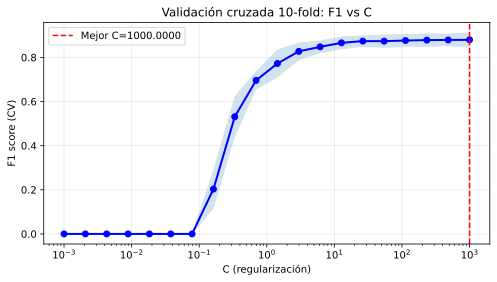

In [15]:
# Visualizamos los resultados de la validación cruzada
mean_scores = clf.cv_results_['mean_test_score']
std_scores = clf.cv_results_['std_test_score']

plt.figure(figsize=(8, 4))
plt.semilogx(rango_C, mean_scores, 'b-o', lw=2)
plt.fill_between(rango_C, mean_scores - std_scores, mean_scores + std_scores, alpha=0.2)
plt.axvline(clf.best_params_['C'], color='r', linestyle='--', label=f"Mejor C={clf.best_params_['C']:.4f}")
plt.xlabel('C (regularización)')
plt.ylabel('F1 score (CV)')
plt.title('Validación cruzada 10-fold: F1 vs C')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [16]:
# Predicciones sobre test
preds_test = clf.predict(X_test)

# Informe de clasificación completo
print("Classification Report (test):")
print(classification_report(Y_test, preds_test, target_names=['no crude', 'crude']))

Classification Report (test):
              precision    recall  f1-score   support

    no crude       0.99      1.00      0.99      3064
       crude       0.91      0.86      0.89       173

    accuracy                           0.99      3237
   macro avg       0.95      0.93      0.94      3237
weighted avg       0.99      0.99      0.99      3237



---
## Paso 6: Curva de Precisión-Recall y F1 Score

Mostramos la curva PR y el F1 score tal como se hace en la **Sesión 5** (celda 72).

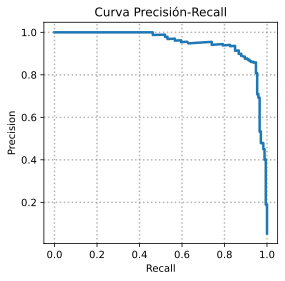

F1 score en el conjunto de TEST = 0.89


In [17]:
# Curva Precisión-Recall (Sesión 5, celda 72)
probs_test = clf.predict_proba(X_test)[:, 1]

precision_test, recall_test, th = precision_recall_curve(Y_test, probs_test, pos_label=1)

fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot()
ax.set_aspect('equal', adjustable='box')

plt.plot(recall_test, precision_test, lw=2.5)
plt.grid(which='major', color='gray', alpha=0.6, linestyle='dotted', lw=1.5)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precisión-Recall')
plt.show()

F1_score_test = f1_score(Y_test, preds_test)
print("F1 score en el conjunto de TEST = {0:.2f}".format(F1_score_test))

In [18]:
# Métricas adicionales (Sesión 5, celda 66)
print(f"Precision en TEST: {precision_score(Y_test, preds_test):.2f}")
print(f"Recall en TEST:    {recall_score(Y_test, preds_test):.2f}")
print(f"F1 score en TEST:  {f1_score(Y_test, preds_test):.2f}")

Precision en TEST: 0.91
Recall en TEST:    0.86
F1 score en TEST:  0.89


---
## Resumen de técnicas y optimizaciones

| Paso | Técnica | Sesión | Optimización M2 Pro |
|------|---------|--------|--------------------|
| Acceso corpus | `nltk.corpus.reuters` | S2 (sec 3) | — |
| Preprocesado | `normalize_Spacy` (lema, stopwords, punct) | S2 (sec 4.5) | `spacy[apple]` + `nlp.pipe(batch=256)` + `disable=['ner','parser']` |
| Vocabulario | `gensim.corpora.Dictionary` + `filter_extremes` | S3 (sec 2.1-2.2) | — |
| BoW | `Vocab.doc2bow()` | S3 (sec 3) | — |
| TF-IDF | `gensim.models.TfidfModel` | S3 (sec 4) / S4 (sec 2) | — |
| Sparse | `corpus2csc` → `.T.tocsr()` | S3 (sec 6.1) | Formato CSR nativo para sklearn |
| Norm L2 | `normalize_sparse_vector()` | S3 (sec 7.3) | `sparse.diags @ s` (aprovecha Accelerate BLAS) |
| Train/Test | `train_test_split(stratify=Y)` | S5 (celda 39) | — |
| Clasificador | `LogisticRegression(penalty='l2')` | S5 (sec 1) | `solver='saga'` (eficiente sparse + BLAS) |
| Val. cruzada | `GridSearchCV` 10-fold | S5 (celda 41) | `n_jobs=-1` (10-12 cores en paralelo) |
| Curva PR | `precision_recall_curve` | S5 (celda 72) | — |
| Métricas | `f1_score`, `precision_score`, `recall_score` | S5 (celda 66) | — |